# Exploratory Data Analysis (EDA)

This notebook explores the Near-Infrared (NIR) spectroscopy dataset used to predict wood moisture content.

---

## 探索的データ分析（EDA）

このノートブックでは、木材の含水率を予測するための近赤外スペクトルデータを探索します。

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.decomposition import PCA

In [2]:
train = pd.read_csv(
    "/Users/maggie/Documents/GitHub/NIR-Spectroscopy-Moisture-Prediction-Using-Machine-Learning/data/train.csv",
    encoding="cp932"
)

test = pd.read_csv(
    "/Users/maggie/Documents/GitHub/NIR-Spectroscopy-Moisture-Prediction-Using-Machine-Learning/data/test.csv",
    encoding="cp932"
)

In [3]:
train.head()

,sample number,species number,樹種,含水率,9993.76781,9989.9107,9986.05359,9982.19648,9978.33937,9974.48227,...,4034.53536,4030.67826,4026.82115,4022.96404,4019.10693,4015.24982,4011.39271,4007.5356,4003.6785,3999.82139
0,1,1,イチョウ,216.129032,0.41485,0.41465,0.41463,0.41476,0.41481,0.41470,...,1.25104,1.24925,1.24145,1.23620,1.23384,1.22981,1.22818,1.23087,1.23354,1.23219
1,2,1,イチョウ,210.752688,0.42049,0.42040,0.42049,0.42053,0.42038,0.42010,...,1.21929,1.21611,1.21565,1.21745,1.21680,1.21205,1.21074,1.21508,1.21901,1.21846
2,3,1,イチョウ,205.913979,0.41040,0.41045,0.41047,0.41028,0.41000,0.40989,...,1.17471,1.17147,1.16611,1.16633,1.16998,1.16955,1.16200,1.15341,1.15139,1.15403
3,4,1,イチョウ,201.075269,0.40080,0.40061,0.40031,0.40008,0.39993,0.39991,...,1.11271,1.11339,1.11115,1.10965,1.11017,1.11165,1.11426,1.11787,1.11849,1.11328
4,5,1,イチョウ,196.236559,0.38792,0.38814,0.38825,0.38817,0.38798,0.38778,...,1.05617,1.05596,1.05760,1.06014,1.06240,1.06566,1.06962,1.07056,1.06459,1.05612


In [4]:
train.shape

(1322, 1559)

In [5]:
# metadata columns
metadata = train.iloc[:, :4]

# target variable
y = train["含水率"]

# spectral features
X = train.iloc[:, 4:]

In [6]:
metadata.head()

,sample number,species number,樹種,含水率
0,1,1,イチョウ,216.129032
1,2,1,イチョウ,210.752688
2,3,1,イチョウ,205.913979
3,4,1,イチョウ,201.075269
4,5,1,イチョウ,196.236559


In [7]:
y.head()

0    216.129032
1    210.752688
2    205.913979
3    201.075269
4    196.236559
Name: 含水率, dtype: float64

In [8]:
X.shape

(1322, 1555)

In [9]:
wavenumbers = X.columns.astype(float)

In [10]:
wavenumbers[:10]

Index([9993.76781,  9989.9107, 9986.05359, 9982.19648, 9978.33937, 9974.48227,
       9970.62516, 9966.76805, 9962.91094, 9959.05383],
      dtype='float64')

In [11]:
print("Max wavenumber:", wavenumbers.max())
print("Min wavenumber:", wavenumbers.min())
print("Total spectral features:", len(wavenumbers))

Max wavenumber: 9993.76781
Min wavenumber: 3999.82139
Total spectral features: 1555


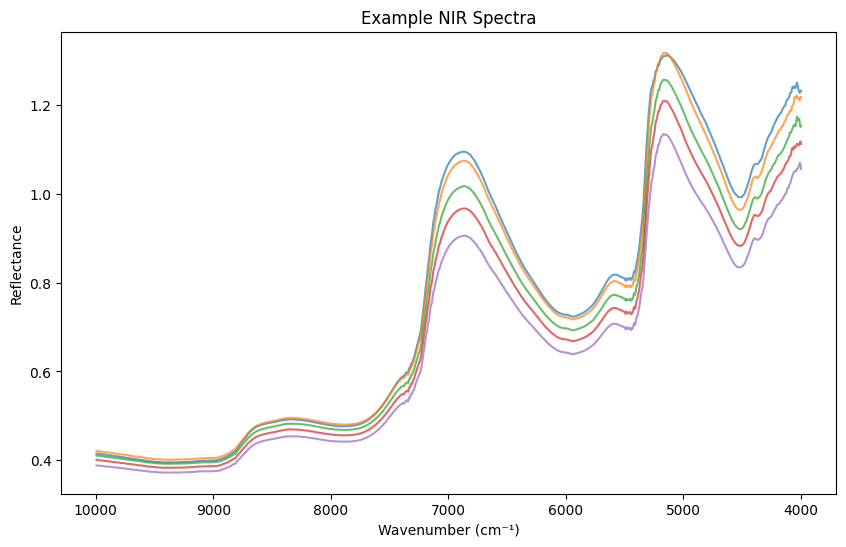

In [12]:
plt.figure(figsize=(10,6))

for i in range(5):
    plt.plot(wavenumbers, X.iloc[i], alpha=0.7)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Reflectance")
plt.title("Example NIR Spectra")

plt.gca().invert_xaxis()

plt.show()

In [13]:
y.describe()

count    1322.000000
mean       49.937672
std        49.543466
min         0.840336
25%        16.114458
50%        29.052870
75%        70.264035
max       298.581560
Name: 含水率, dtype: float64

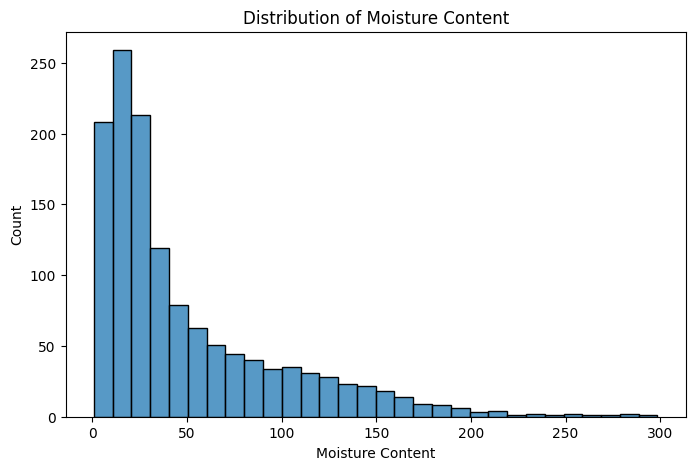

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(y, bins=30)

plt.xlabel("Moisture Content")
plt.title("Distribution of Moisture Content")

plt.show()

/opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


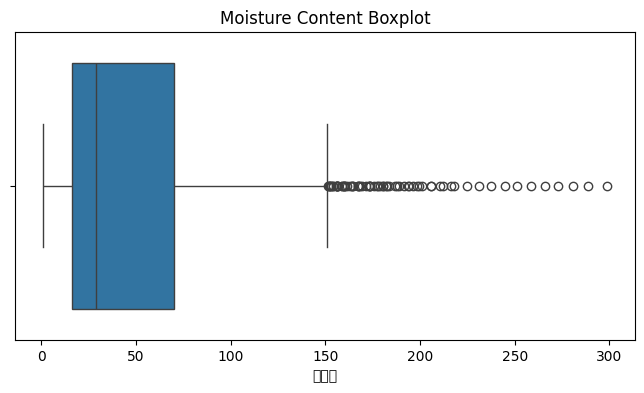

In [15]:
plt.figure(figsize=(8,4))

sns.boxplot(x=y)

plt.title("Moisture Content Boxplot")

plt.show()

In [16]:
train["species number"].nunique()

13

In [17]:
train["species number"].value_counts()

species number
12    183
14    141
15    112
4     110
13    107
8      97
1      94
17     93
5      91
11     88
3      87
16     68
19     51
Name: count, dtype: int64

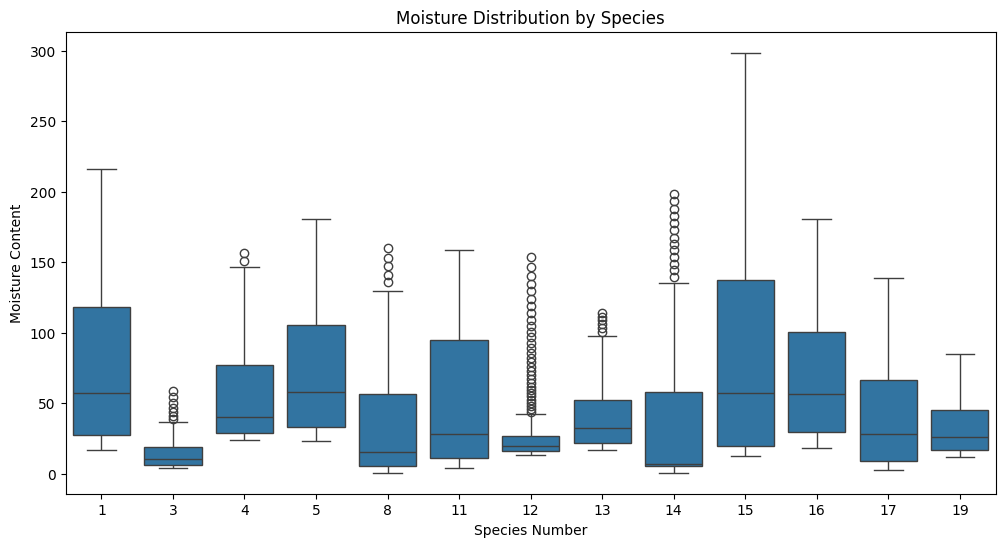

In [18]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x=train["species number"],
    y=y
)

plt.xlabel("Species Number")
plt.ylabel("Moisture Content")
plt.title("Moisture Distribution by Species")

plt.show()

In [19]:
species_spectra = train.groupby("species number")[X.columns].mean()

In [20]:
species_spectra.shape

(13, 1555)

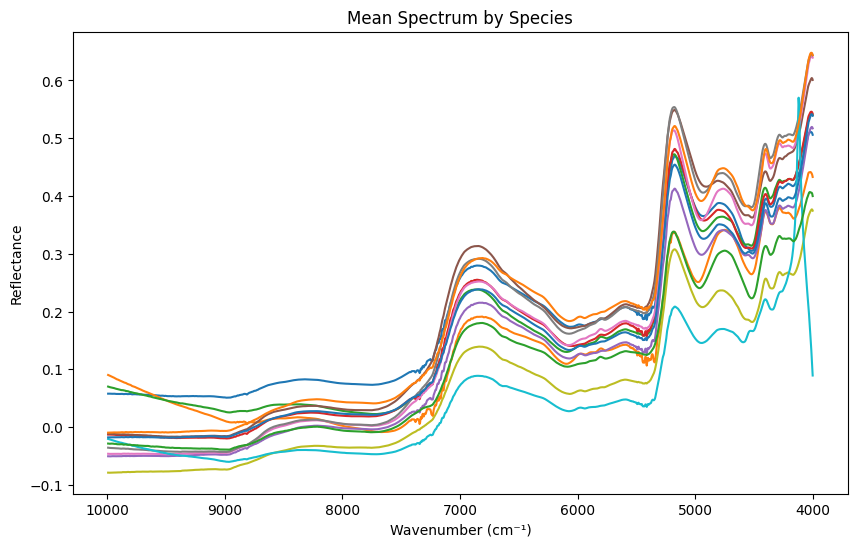

In [21]:
plt.figure(figsize=(10,6))

for sp in species_spectra.index:
    plt.plot(wavenumbers, species_spectra.loc[sp])

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Reflectance")
plt.title("Mean Spectrum by Species")

plt.gca().invert_xaxis()

plt.show()

In [22]:
correlations = X.corrwith(y)

In [23]:
correlations.abs().sort_values(ascending=False).head(10)

7617.78905    0.779093
7621.64616    0.779083
7613.93194    0.779063
7625.50326    0.779028
7610.07483    0.779021
7633.21748    0.778993
7629.36037    0.778988
7606.21772    0.778983
7637.07459    0.778971
7602.36061    0.778946
dtype: float64

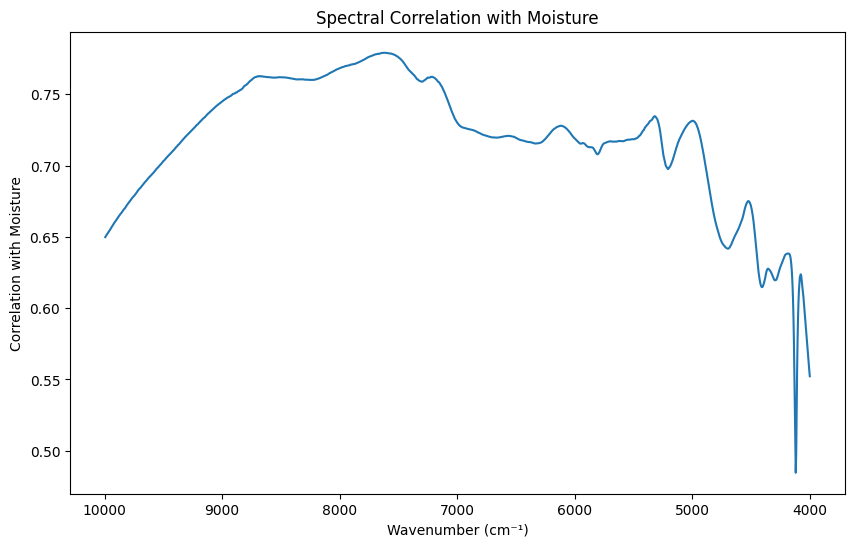

In [24]:
plt.figure(figsize=(10,6))

plt.plot(wavenumbers, correlations)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Correlation with Moisture")
plt.title("Spectral Correlation with Moisture")

plt.gca().invert_xaxis()

plt.show()

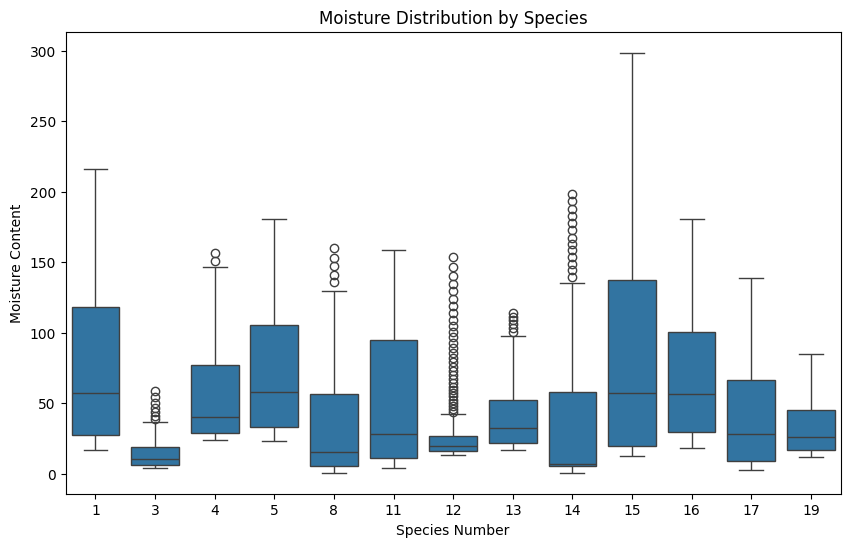

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(x="species number", y="含水率", data=train)

plt.title("Moisture Distribution by Species")
plt.xlabel("Species Number")
plt.ylabel("Moisture Content")

plt.show()

In [26]:
train.groupby("species number")["含水率"].describe()

,count,mean,std,min,25%,50%,75%,max
species number,,,,,,,,
1,94.0,77.991306,58.375580,17.204301,27.688172,57.258065,118.010753,216.129032
3,87.0,15.461847,12.395327,4.216867,6.626506,10.843373,19.277108,58.734940
4,110.0,57.219697,36.561529,24.166667,28.854167,40.625000,76.979167,156.250000
5,91.0,73.165228,45.836254,23.214286,33.258929,58.035714,105.803571,180.357143
8,97.0,37.074417,42.848894,0.840336,5.462185,15.546218,56.722689,160.084034
11,88.0,53.380800,49.720184,4.149378,11.618257,28.423237,95.020747,158.921162
12,183.0,31.619374,29.253417,13.253012,16.064257,20.080321,26.907631,153.815261
13,107.0,41.790332,25.678688,16.932907,21.884984,32.587859,52.555911,114.057508
14,141.0,39.609585,53.227156,0.970874,5.825243,7.281553,58.252427,198.543689


In [27]:
train.groupby("species number")["含水率"].agg(["mean","median","std","min","max"])

,mean,median,std,min,max
species number,,,,,
1,77.991306,57.258065,58.375580,17.204301,216.129032
3,15.461847,10.843373,12.395327,4.216867,58.734940
4,57.219697,40.625000,36.561529,24.166667,156.250000
5,73.165228,58.035714,45.836254,23.214286,180.357143
8,37.074417,15.546218,42.848894,0.840336,160.084034
11,53.380800,28.423237,49.720184,4.149378,158.921162
12,31.619374,20.080321,29.253417,13.253012,153.815261
13,41.790332,32.587859,25.678688,16.932907,114.057508
14,39.609585,7.281553,53.227156,0.970874,198.543689


In [28]:
X.iloc[:, :50].corr()

,9993.76781,9989.9107,9986.05359,9982.19648,9978.33937,9974.48227,9970.62516,9966.76805,9962.91094,9959.05383,...,9839.48347,9835.62636,9831.76926,9827.91215,9824.05504,9820.19793,9816.34082,9812.48371,9808.62661,9804.7695
9993.76781,1.000000,0.999999,0.999995,0.999991,0.999985,0.999978,0.999969,0.999958,0.999946,0.999931,...,0.998796,0.998729,0.998662,0.998598,0.998537,0.998479,0.998426,0.998375,0.998315,0.998246
9989.9107,0.999999,1.000000,0.999999,0.999996,0.999992,0.999986,0.999979,0.999969,0.999959,0.999946,...,0.998859,0.998793,0.998727,0.998664,0.998605,0.998549,0.998498,0.998448,0.998390,0.998323
9986.05359,0.999995,0.999999,1.000000,0.999999,0.999996,0.999992,0.999986,0.999978,0.999969,0.999958,...,0.998920,0.998855,0.998790,0.998729,0.998671,0.998617,0.998567,0.998520,0.998463,0.998397
9982.19648,0.999991,0.999996,0.999999,1.000000,0.999999,0.999996,0.999991,0.999985,0.999978,0.999967,...,0.998977,0.998913,0.998849,0.998790,0.998734,0.998680,0.998632,0.998586,0.998531,0.998466
9978.33937,0.999985,0.999992,0.999996,0.999999,1.000000,0.999999,0.999995,0.999990,0.999984,0.999976,...,0.999028,0.998965,0.998903,0.998845,0.998790,0.998738,0.998691,0.998646,0.998592,0.998529
9974.48227,0.999978,0.999986,0.999992,0.999996,0.999999,1.000000,0.999999,0.999995,0.999991,0.999984,...,0.999082,0.999022,0.998962,0.998905,0.998852,0.998801,0.998755,0.998711,0.998658,0.998596
9970.62516,0.999969,0.999979,0.999986,0.999991,0.999995,0.999999,1.000000,0.999999,0.999996,0.999991,...,0.999139,0.999081,0.999023,0.998968,0.998916,0.998866,0.998822,0.998778,0.998727,0.998666
9966.76805,0.999958,0.999969,0.999978,0.999985,0.999990,0.999995,0.999999,1.000000,0.999999,0.999995,...,0.999192,0.999135,0.999079,0.999025,0.998974,0.998926,0.998883,0.998841,0.998791,0.998732
9962.91094,0.999946,0.999959,0.999969,0.999978,0.999984,0.999991,0.999996,0.999999,1.000000,0.999999,...,0.999242,0.999187,0.999133,0.999080,0.999031,0.998985,0.998943,0.998902,0.998853,0.998795
9959.05383,0.999931,0.999946,0.999958,0.999967,0.999976,0.999984,0.999991,0.999995,0.999999,1.000000,...,0.999294,0.999242,0.999189,0.999139,0.999091,0.999046,0.999004,0.998964,0.998916,0.998860


In [29]:
train.isnull().sum().sum()

np.int64(0)

In [43]:
wood_palette = [
    "#f5deb3",  # wheat / light sapwood
    "#e6c79c",  # pale oak
    "#d2b48c",  # tan
    "#deb887",  # burlywood
    "#c8a165",  # light oak
    "#b8894f",  # golden oak
    "#a67843",  # aged oak
    "#96613b",  # cedar
    "#8b5a2b",  # walnut
    "#7a4a2a",  # dark walnut
    "#6b3e26",  # bark brown
    "#5c4033",  # dark bark
    "#4b3621"   # deep wood
]

/var/folders/01/5r6f25414h3f57k6hs6f66z40000gn/T/ipykernel_2348/769192708.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


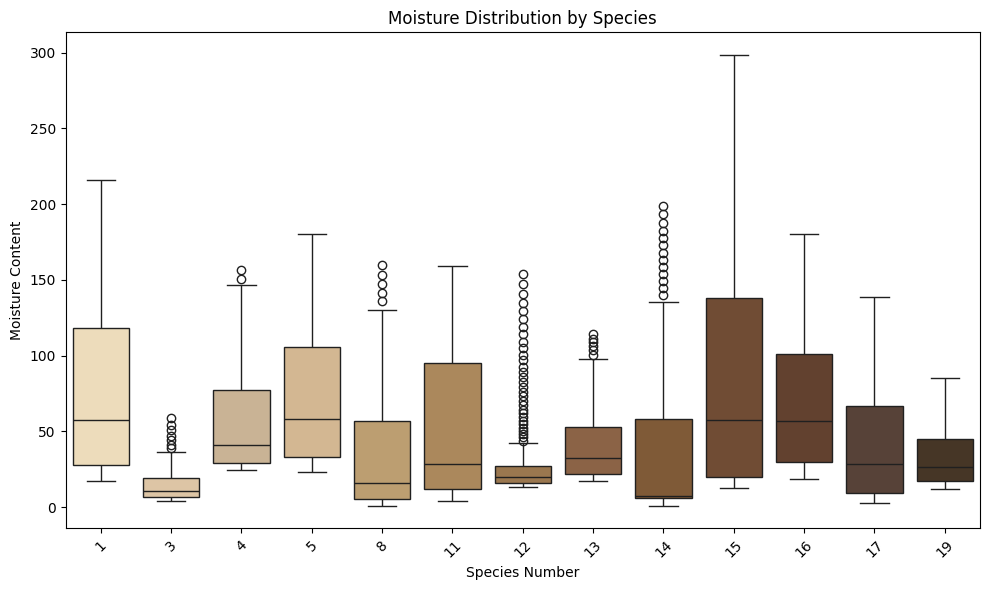

In [50]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='species number',
    y='含水率',
    data=train,
    palette=wood_palette,
    legend=False
)

plt.title("Moisture Distribution by Species")
plt.xlabel("Species Number")
plt.ylabel("Moisture Content")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("/Users/maggie/Documents/GitHub/NIR-Spectroscopy-Moisture-Prediction-Using-Machine-Learning/docs/moisture_by_species.png", bbox_inches="tight")

plt.show()

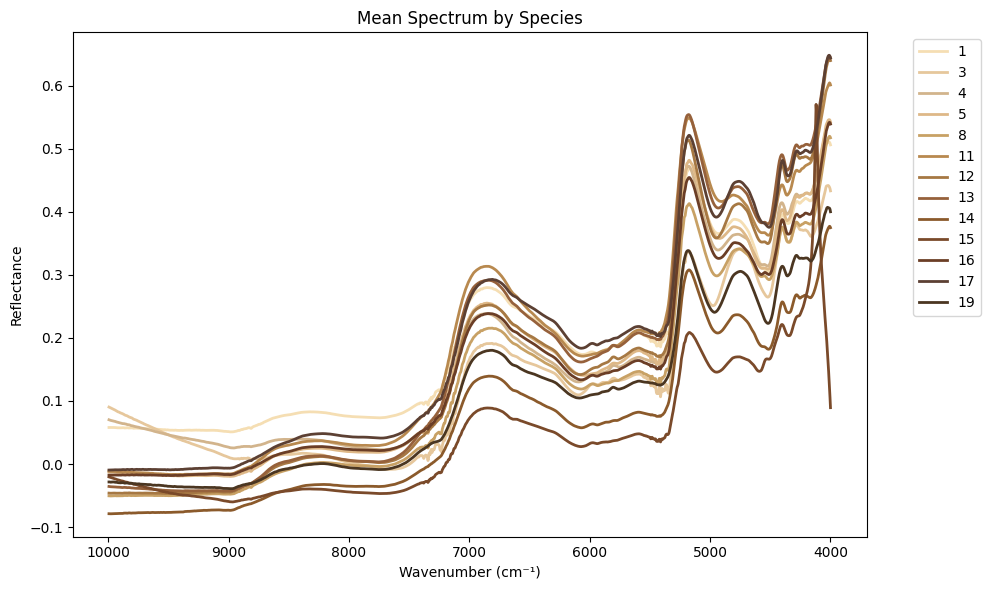

In [56]:
plt.figure(figsize=(10,6))

for i, sp in enumerate(species_spectra.index):
    plt.plot(wavenumbers, species_spectra.loc[sp],
             color=wood_palette[i % len(wood_palette)],
             linewidth=2,
             label=sp)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Reflectance")
plt.title("Mean Spectrum by Species")

plt.gca().invert_xaxis()
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()
plt.savefig("/Users/maggie/Documents/GitHub/NIR-Spectroscopy-Moisture-Prediction-Using-Machine-Learning/docs/mean_spectrum.png", bbox_inches="tight")

plt.show()

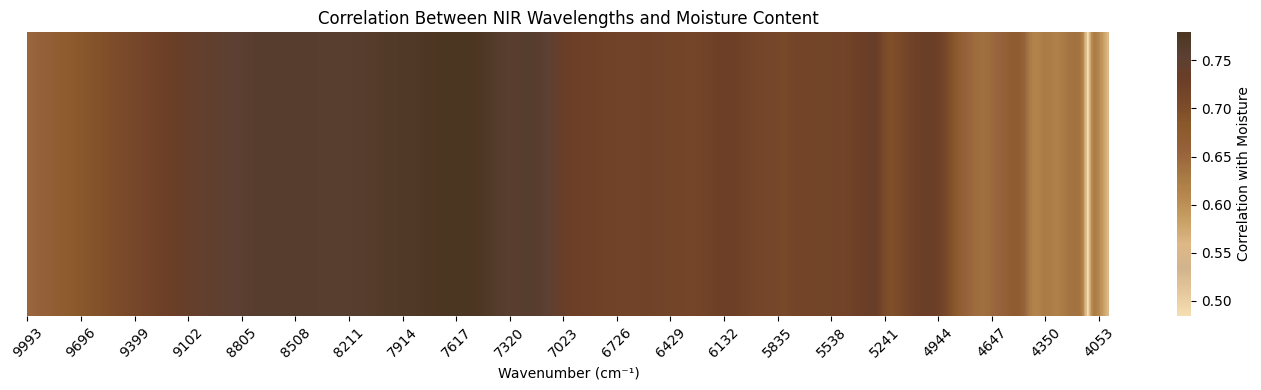

In [59]:
# Convert palette to colormap
wood_cmap = LinearSegmentedColormap.from_list("wood_cmap", wood_palette)

# Select spectral columns (wavelength columns only)
spectral_cols = [c for c in train.columns if str(c).replace('.', '').isdigit()]

# Convert column names to numeric wavenumbers
wavenumbers = np.array(spectral_cols, dtype=float)

# Calculate correlation with moisture
moisture_corr = train[spectral_cols].corrwith(train['含水率'])

# Format for heatmap
heatmap_data = moisture_corr.values.reshape(1, -1)

plt.figure(figsize=(14,4))

sns.heatmap(
    heatmap_data,
    cmap=wood_cmap,
    cbar_kws={"label": "Correlation with Moisture"}
)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.yticks([])
plt.title("Correlation Between NIR Wavelengths and Moisture Content")

# Reduce tick clutter
step = max(1, len(wavenumbers)//20)
plt.xticks(
    ticks=np.arange(0, len(wavenumbers), step),
    labels=wavenumbers[::step].astype(int),
    rotation=45
)

plt.tight_layout()

plt.savefig(
"/Users/maggie/Documents/GitHub/NIR-Spectroscopy-Moisture-Prediction-Using-Machine-Learning/docs/moisture_correlation_heatmap.png",
bbox_inches="tight",
dpi=300
)

plt.show()

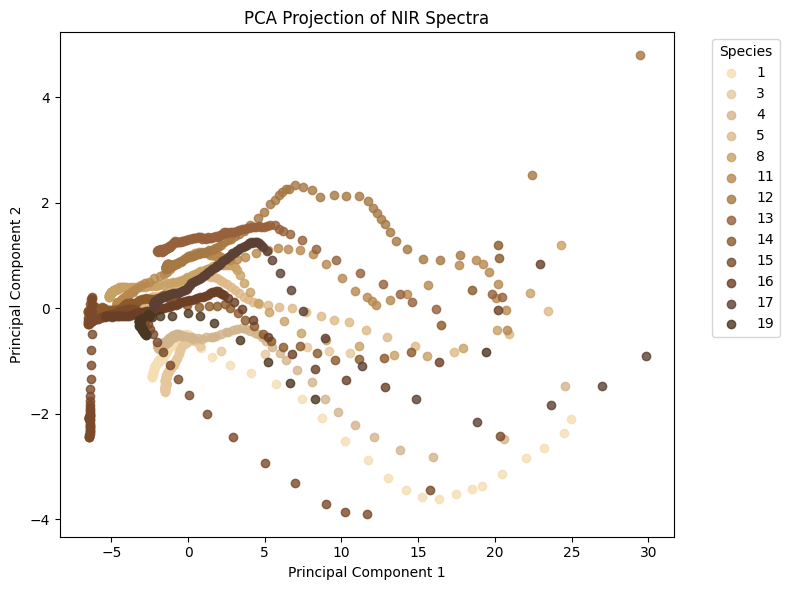

In [61]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Select spectral columns (numeric wavelength columns only)
spectral_cols = [c for c in train.columns if str(c).replace('.', '').isdigit()]

X = train[spectral_cols]

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Species labels
species = train['species number']

# Wood palette
wood_palette = [
"#f5deb3","#e6c79c","#d2b48c","#deb887","#c8a165",
"#b8894f","#a67843","#96613b","#8b5a2b",
"#7a4a2a","#6b3e26","#5c4033","#4b3621"
]

# Plot
plt.figure(figsize=(8,6))

unique_species = sorted(species.unique())

for i, sp in enumerate(unique_species):
    
    mask = species == sp
    
    plt.scatter(
        X_pca[mask,0],
        X_pca[mask,1],
        color=wood_palette[i % len(wood_palette)],
        label=sp,
        alpha=0.8
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of NIR Spectra")

plt.legend(title="Species", bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()

plt.savefig(
"/Users/maggie/Documents/GitHub/NIR-Spectroscopy-Moisture-Prediction-Using-Machine-Learning/docs/pca_spectral_clusters.png",
bbox_inches="tight",
dpi=300
)

plt.show()

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Select spectral columns (numeric wavelength columns only)
spectral_cols = [c for c in train.columns if str(c).replace('.', '').isdigit()]

# Features and target
X = train[spectral_cols]
y = train['含水率']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Ridge Regression model
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 16.886337190788044
R²: 0.8733314376848649
